## 线性回归

### 线性模型
给定 $n$ 维输入 $\mathbf{x} = [x_1, x_2, \ldots, x_n]^T$。  
模型有 $n$ 维权重和一个标量偏差 $b$。  
$$
\mathbf{w} = [w_1, w_2, \ldots, w_n]^T
$$
输出为输入的加权和：  
$$
y = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
$$
向量形式：  
$$
y = \mathbf{w}^T \mathbf{x} + b
$$

### 损失函数
线性回归通常使用平方损失函数衡量预测值与真实值之间的误差。  
若第 $i$ 个样本的真实值为 $y^{(i)}$，预测值为 $\hat{y}^{(i)}$，则单个样本的损失为：  
$$
l^{(i)} = \frac{1}{2} \left( \hat{y}^{(i)} - y^{(i)} \right)^2
$$
在整个训练集上的平均损失为：  
$$
L = \frac{1}{n} \sum_{i=1}^{n} \frac{1}{2} \left( \hat{y}^{(i)} - y^{(i)} \right)^2
$$

### 训练数据
训练数据由输入特征和真实标签组成。  
输入特征记为 $\mathbf{x} = [x_1, x_2, \ldots, x_n]$，真实标签记为 $y$。  
例如在房价预测中，一个样本可以表示为：  
$$
\mathbf{x} = [\text{卧室数},\ \text{卫生间数},\ \text{居住面积}]
$$
$$
y = \text{房屋成交价}
$$
全部训练数据可记为：  
$$
\left\{ \left( \mathbf{x}^{(1)}, y^{(1)} \right), \left( \mathbf{x}^{(2)}, y^{(2)} \right), \ldots, \left( \mathbf{x}^{(m)}, y^{(m)} \right) \right\}
$$

## 基础优化算法

### 梯度下降
- 挑选一个初始值 $\mathbf{w}_0$
- 重复迭代参数 $t=1,2,3,\ldots$
$$
\mathbf{w}_t = \mathbf{w}_{t-1} - \eta \frac{\partial \ell}{\partial \mathbf{w}_{t-1}}
$$
- 沿梯度方向将增加损失函数值
- 学习率 $\eta$：步长的超参数


### 小批量随机梯度下降
- 在整个训练集上算梯度太贵
  - 一个深度神经网络模型可能需要数分钟至数小时
- 我们可以随机采样 $b$ 个样本 $i_1, i_2, \ldots, i_b$ 来近似损失
$$
\frac{1}{b} \sum_{i \in I_b} \ell(\mathbf{x}_i, y_i, \mathbf{w})
$$
- $b$ 是批量大小，另一个重要的超参数

### 总结
- 梯度下降通过不断沿着反梯度方向更新参数求解
- 小批量随机梯度下降是深度学习默认的求解算法
- 两个重要的超参数是批量大小和学习率

## 线性回归的从零开始实现

In [1]:
import random
import torch

### 人造数据集的生成
根据带有噪声的线性模型构造一个人造数据集。我们使用线性模型参数
$$
\mathbf{w} = [2,\ -3.4]^\top,\quad b = 4.2
$$
和噪声项 $\epsilon$ 生成数据集及其标签。
$$
\mathbf{y} = \mathbf{Xw} + b + \epsilon
$$

In [2]:
def synthetic_data(w,b,num_examples):
    #生成 y = Xw + b + 噪声。
    x = torch.normal(0,2,(num_examples,len(w)))
    y = torch.matmul(x, w) + b
    y += torch.normal(0,0.01,y.shape)
    return x,y.reshape((-1,1))

true_w = torch.tensor([2,-3.4])
true_b = 4.2
features, labels = synthetic_data(true_w,true_b,1000)

#### features中的每一行都包含一个二维数据样本，labels中的每一行都包含一位标签值（一个标量）

In [3]:
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([-0.1188,  0.6568]) 
label: tensor([1.7242])


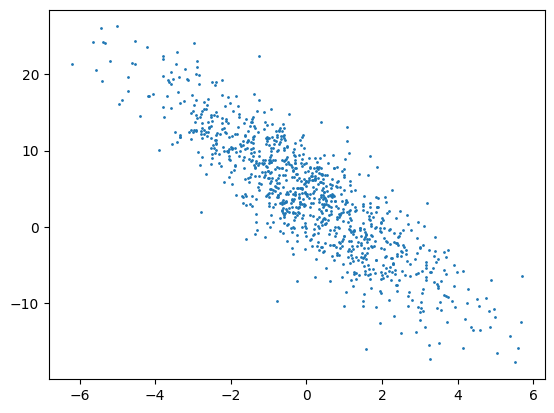

In [4]:
import matplotlib.pyplot as plt
plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1)
plt.show()

#### 定义一个data_iter函数，该函数接受批量大小，特征矩阵和标签向量作为输入，生成大小为batch_size的小批量

In [5]:
def data_iter(batch_size,features,labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)  # 样本的读取顺序是随机的。
    for i in range(0,num_examples,batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]
    
batch_size = 10

for x,y in data_iter(batch_size,features,labels):
    print(x,'\n',y)
    break

tensor([[ 1.0936, -2.6456],
        [ 3.3112, -0.1658],
        [ 2.8056, -0.6250],
        [ 0.5630,  3.2855],
        [ 2.7986, -1.0502],
        [-1.5902, -0.6399],
        [-0.2198,  1.2663],
        [ 2.5205, -5.0063],
        [ 1.7123, -5.4255],
        [-3.0334,  0.7316]]) 
 tensor([[15.3980],
        [11.3789],
        [11.9290],
        [-5.8567],
        [13.3606],
        [ 3.2025],
        [-0.5350],
        [26.2578],
        [26.0682],
        [-4.3387]])


#### 定义初始化模型参数

In [6]:
w = torch.normal(0,0.01,size=(2,1),requires_grad=True)
b = torch.zeros(1,requires_grad=True)
params = [w,b]

#### 定义模型

In [7]:
def linreg(x,w,b):
    '''线性回归模型。'''
    return torch.matmul(x,w) + b

#### 定义损失函数

In [8]:
def squared_loss(y_hat,y):
    '''均方损失'''
    return (y_hat - y.reshape(y_hat.shape))** 2 / 2

#### 定义优化算法

In [9]:
def sgd(params,lr,batch_size):
    '''小批量随机梯度下降'''
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

#### 训练工程

In [10]:
lr = 0.1
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for x, y in data_iter(batch_size, features, labels):
        l = loss(net(x,w,b),y) # 'x' 和 'y' 的小批量损失
        l.sum().backward()
        sgd([w,b],lr,batch_size) # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')


epoch 1, loss 0.000052
epoch 2, loss 0.000062
epoch 3, loss 0.000050


#### 比较真实参数和通过训练学到的参数来评估训练的成功程度

In [11]:
print(f'w的估计误差：{true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差：{true_b - b}')

w的估计误差：tensor([-0.0009, -0.0001], grad_fn=<SubBackward0>)
b的估计误差：tensor([-0.0006], grad_fn=<RsubBackward1>)


## 线性回归的简洁实现

In [12]:
import numpy as np
import torch
from torch.utils import data 

true_w = torch.tensor([2,-3.4])
true_b = 4.2
features,labels = synthetic_data(true_w,true_b,1000)

In [13]:
def load_array(data_arrays,batch_size,is_train=True):
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle=is_train)

batch_size = 10
data_iter = load_array((features,labels),batch_size)

next(iter(data_iter))

[tensor([[ 2.3875, -3.1993],
         [ 1.5716, -1.7333],
         [ 0.1419, -1.1437],
         [-1.0345,  4.5580],
         [-1.2000, -0.1695],
         [ 0.9923,  1.8966],
         [ 0.2752,  2.1080],
         [ 1.1622, -2.3836],
         [ 1.8152, -0.8220],
         [-0.7603, -0.2743]]),
 tensor([[ 19.8398],
         [ 13.2248],
         [  8.3807],
         [-13.3611],
         [  2.3620],
         [ -0.2823],
         [ -2.4253],
         [ 14.6309],
         [ 10.6308],
         [  3.6139]])]

In [14]:
from torch import nn # PyTorch神经网络模块

net = nn.Sequential(nn.Linear(2,1))

#### 初始化模型参数

In [15]:
net[0].weight.data.normal_(0,0.01)      
net[0].bias.data.fill_(0)

tensor([0.])

#### 计算均方误差使用的是MSELoss类，也称平方范数

In [16]:
loss = nn.MSELoss()

#### 实例化SGD实例

In [17]:
trainer = torch.optim.SGD(net.parameters(), lr = 0.03)

#### 训练代码

In [18]:
num_epochs = 3
for epoch in range(num_epochs):
    for x,y in data_iter:
        l = loss(net(x),y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    with torch.no_grad():
        train_l = loss(net(features),labels)
        print(f'epoch {epoch + 1}, loss {float(train_l):f}')    

epoch 1, loss 0.000199
epoch 2, loss 0.000107
epoch 3, loss 0.000111
